In [1]:
import os
from pathlib import Path

# Get the current directory of the notebook
notebook_path = Path.cwd()

ROOT = notebook_path.parent.parent

# Change the Working Directory for the whole process
os.chdir(ROOT)

print(f"Current Working Directory fixed to: {os.getcwd()}")

Current Working Directory fixed to: /srv/homes/onbo10/thesis_main


In [2]:
from src.Geometry.triangulation.triangulator import Triangulator
import cv2
from src.Geometry.triangulation.triangulation_utils import *
from utilities.visualizer import TriangulationVisualizer
import matplotlib.pyplot as plt

In [3]:
left_mask_path = "data/Surgpose_for_segmentation/left_test_set/binary_masks/vid_000004_left_frame_000273.png"
frame_id= os.path.basename(left_mask_path).split('.')[0]
right_mask_path = left_mask_path.replace('left', 'right')
zip_calib_path = "data/SurgPose/SurgPose_for_HRNet/000004.zip"
left_img_path = "data/SurgPose/SurgPose_for_HRNet/Extracted/extracted_frames/000004/vid_000004_left_frame_000273.jpg"
right_img_path = "data/SurgPose/SurgPose_for_HRNet/Extracted_right_test/extracted_frames/000004/vid_000004_right_frame_000273.jpg"
raft_disparity_path= 'results/Stereo_matching/Surgpose_test_disparity_maps/npy_disparities/vid_000004_frame_000273.npy'

In [4]:
#Initialize Tools
triangulator = Triangulator()
triangulator.load_calibration(zip_calib_path)
visualizer = TriangulationVisualizer()

#Load Masks
mask_l = cv2.imread(left_mask_path, cv2.IMREAD_GRAYSCALE)
mask_r = cv2.imread(right_mask_path, cv2.IMREAD_GRAYSCALE)
img_l = cv2.imread(left_img_path)
img_r= cv2.imread(right_img_path)
h, w = img_l.shape[:2]


In [5]:
mode = "conventional"
lmap1, lmap2, rmap1, rmap2, q= triangulator.get_rectification_maps(img_size=(h,w), mode=mode)
rect_l, rect_r = triangulator.rectify_images(img_l, img_r,lmap1, lmap2, rmap1, rmap2, mode)
rect_mask_l = cv2.remap(mask_l, lmap1, lmap2, cv2.INTER_NEAREST)
rect_mask_r = cv2.remap(mask_r, rmap1, rmap2, cv2.INTER_NEAREST)


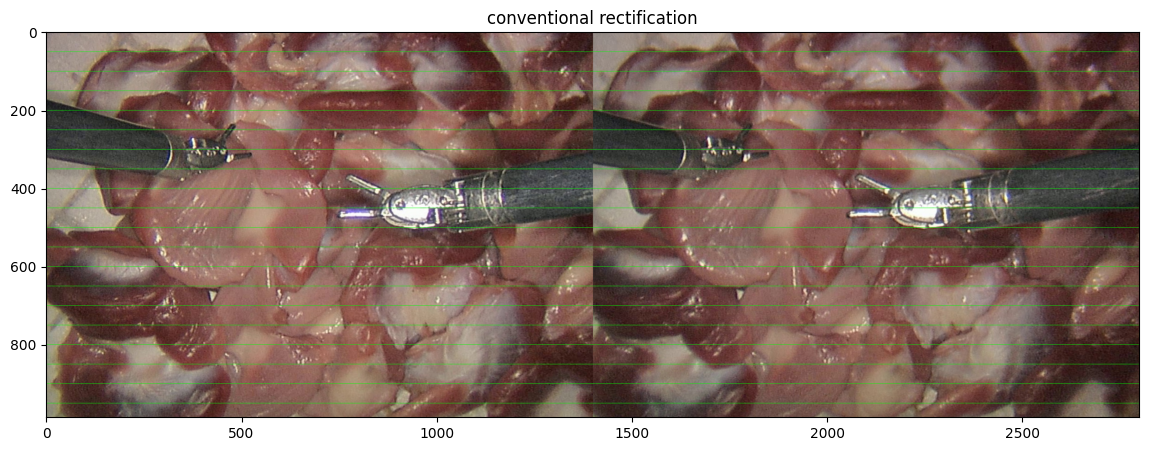

In [6]:
# Create a side-by-side view to see the lines crossing both images continuously
combined = np.hstack((rect_l, rect_r))
h, w, _ = combined.shape

for i in range(0, h, 50):
    cv2.line(combined, (0, i), (w, i), (0, 255, 0), 1)
plt.figure(figsize=(15, 5))
plt.imshow(cv2.cvtColor(combined, cv2.COLOR_BGR2RGB))
plt.title(f"{mode} rectification")
plt.show()

Reconstructing vid_000004_left_frame_000273...


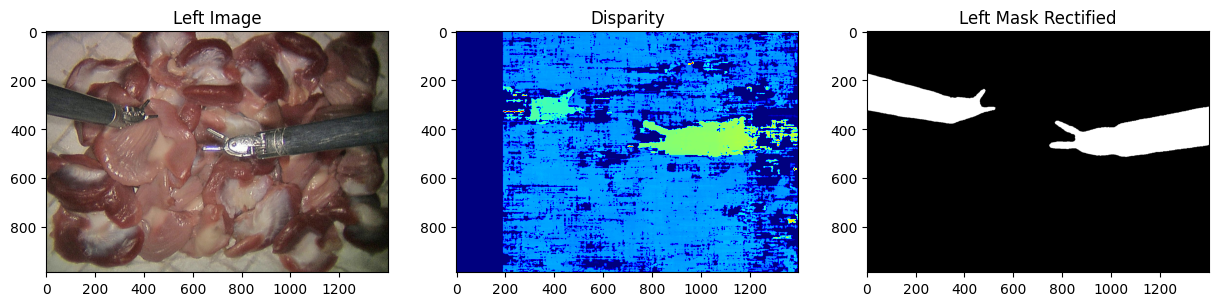

Success! Reconstructed 73069 points.


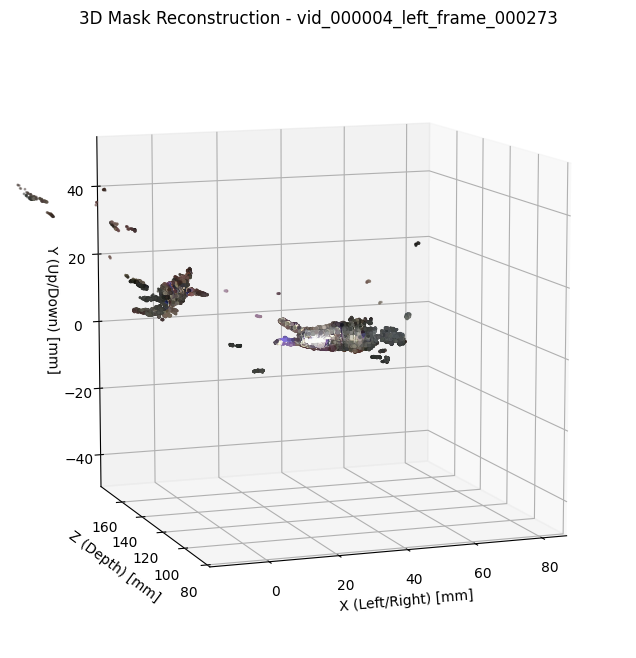

In [7]:

print(f"Reconstructing {frame_id}...")
points_3d_cloud, colors ,disparity = triangulator.reconstruct_3d_sgbm(rect_l, rect_r, q, rect_mask_l)

#Visualize


plt.figure(figsize=(15, 5))
plt.subplot(131); plt.imshow(cv2.cvtColor(img_l, cv2.COLOR_BGR2RGB)); plt.title("Left Image")
plt.subplot(132); plt.imshow(disparity, cmap='jet'); plt.title("Disparity")
plt.subplot(133); plt.imshow(rect_mask_l, cmap='gray'); plt.title("Left Mask Rectified")
plt.show()

if points_3d_cloud.size > 0:
    print(f"Success! Reconstructed {len(points_3d_cloud)} points.")
    visualizer.plot_3d_mask(points_3d_cloud, frame_id,colors=colors,show=True,elevation=10, azimuth=-110)
else:
    print("Reconstruction failed: No matching pixels found along epipolar lines.")

Reconstructing vid_000004_left_frame_000273...


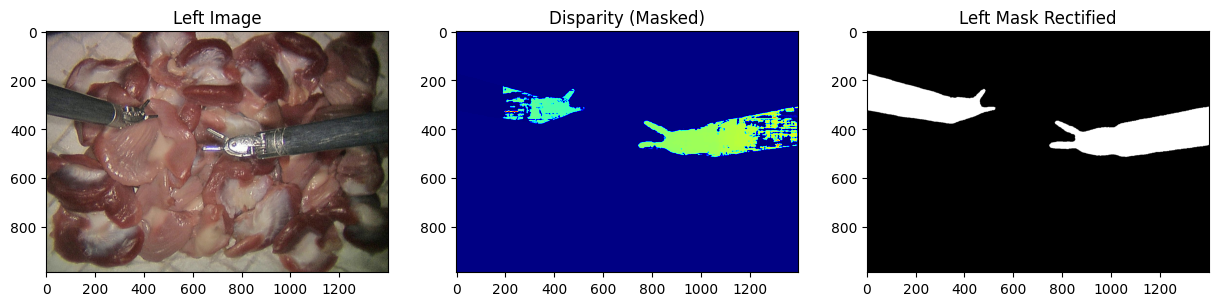

Success! Reconstructed 79634 points.


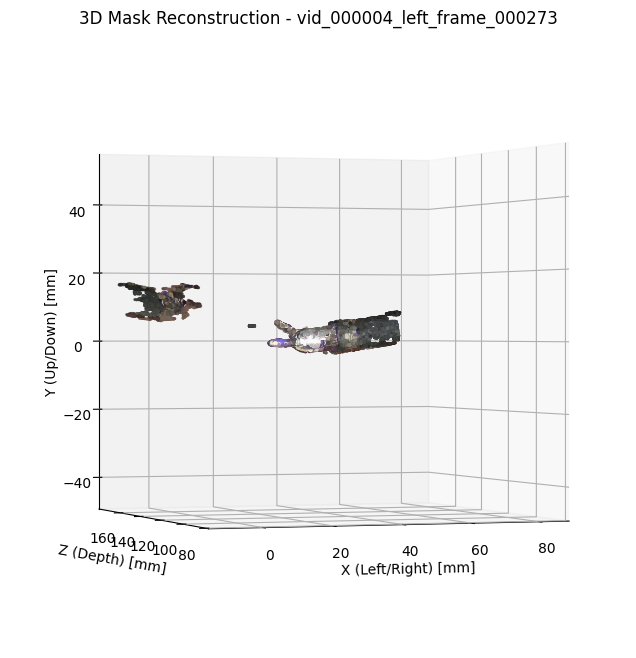

In [8]:
print(f"Reconstructing {frame_id}...")
points_3d_cloud, colors ,disparity = triangulator.reconstruct_3d_sgbm_masked(rect_l, rect_r, q, rect_mask_l, rect_mask_r)

#Visualize


plt.figure(figsize=(15, 5))
plt.subplot(131); plt.imshow(cv2.cvtColor(img_l, cv2.COLOR_BGR2RGB)); plt.title("Left Image")
plt.subplot(132); plt.imshow(disparity*rect_mask_l, cmap='jet'); plt.title("Disparity (Masked)")
plt.subplot(133); plt.imshow(rect_mask_l, cmap='gray'); plt.title("Left Mask Rectified")
plt.show()

if points_3d_cloud.size > 0:
    print(f"Success! Reconstructed {len(points_3d_cloud)} points.")
    visualizer.plot_3d_mask(points_3d_cloud, frame_id,colors=colors,show=True, elevation=0, azimuth=-110)
else:
    print("Reconstruction failed: No matching pixels found along epipolar lines.")

In [9]:
visualizer.plot_3d_plotly(points_3d=points_3d_cloud, colors=colors, frame_name=frame_id)

Reconstructing vid_000004_left_frame_000273...


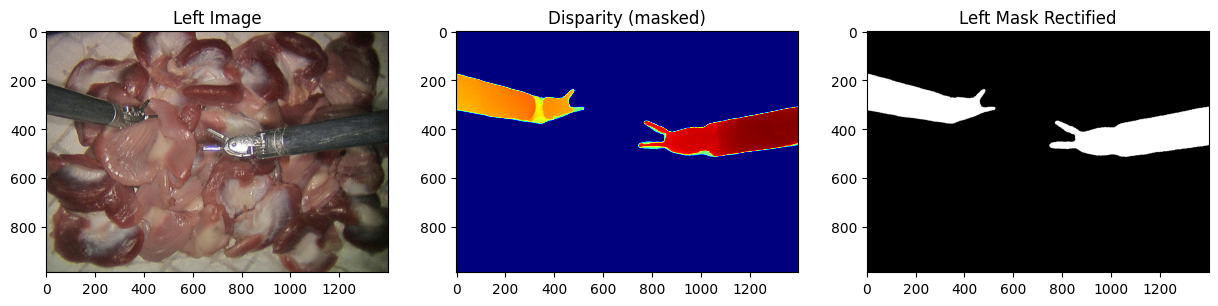

Success! Reconstructed 136587 points.


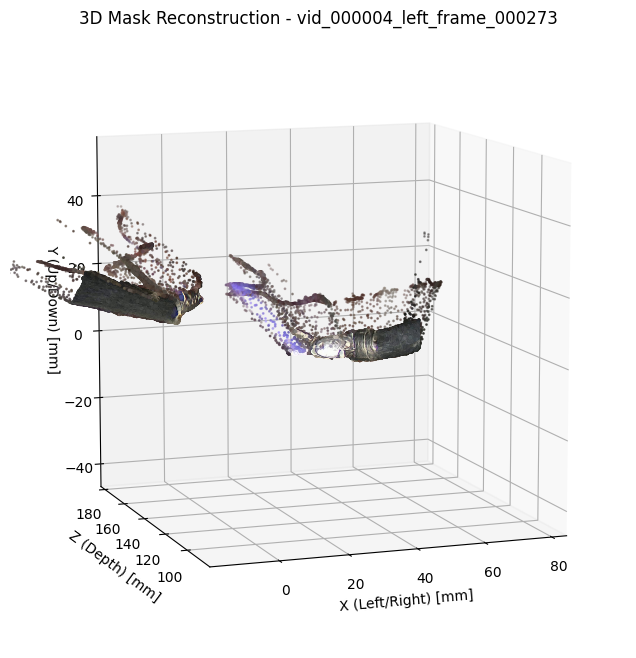

In [10]:
print(f"Reconstructing {frame_id}...")
points_3d_cloud, colors, disparity = triangulator.project_disparity_to_3d(raft_disparity_path, q, rect_l, rect_mask_l)

#Visualize


plt.figure(figsize=(15, 5))
plt.subplot(131); plt.imshow(cv2.cvtColor(img_l, cv2.COLOR_BGR2RGB)); plt.title("Left Image")
plt.subplot(132); plt.imshow(disparity, cmap='jet'); plt.title("Disparity (masked)")
plt.subplot(133); plt.imshow(rect_mask_l, cmap='gray'); plt.title("Left Mask Rectified")
plt.show()

if points_3d_cloud.size > 0:
    print(f"Success! Reconstructed {len(points_3d_cloud)} points.")
    visualizer.plot_3d_mask(points_3d_cloud, frame_id,colors=colors,show=True,elevation=10, azimuth=-110)
else:
    print("Reconstruction failed: No matching pixels found along epipolar lines.")

In [11]:
visualizer.plot_3d_plotly(points_3d=points_3d_cloud, colors=colors, frame_name=frame_id)